# 🩸 Kan Hücresi Anomali Tespiti
## Veri Ön İşleme (Preprocessing) + Keşifsel Veri Analizi (EDA)

**Ödev:** Veri Ön İşleme 5P + EDA 5P = Toplam 10P  
**Veri Seti:** `blood_cell_anomaly_detection.csv` — 5880 gözlem, 36 değişken  
**Hedef Değişken:** `anomaly_label` (0 = Normal, 1 = Anomali)


---
## 0. Kütüphanelerin Yüklenmesi

Projede kullanılacak tüm Python kütüphaneleri burada tek seferde import edilir.
- `pandas` / `numpy`: Veri manipülasyonu ve sayısal işlemler
- `matplotlib` / `seaborn`: Görselleştirme
- `sklearn`: Makine öğrenmesi ön işleme araçları
- `warnings.filterwarnings("ignore")`: Gereksiz uyarı mesajlarını gizler


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print("✓ Kütüphaneler başarıyla yüklendi.")


✓ Kütüphaneler başarıyla yüklendi.


---
# 📦 BÖLÜM 1 — Veri Ön İşleme (Preprocessing) [5 Puan]

Ön işleme adımları ham veriyi makine öğrenmesi modellerine uygun hale getirir.
Aşağıda **5 temel adım** uygulanmaktadır.


### Adım 1 — Veriyi Yükleme ve İlk İnceleme

`pd.read_csv()` ile CSV dosyası okunur ve genel yapı incelenir:
- `.shape`: Satır ve sütun sayısı
- `.head()`: İlk 5 satır görüntüsü
- `.dtypes`: Her sütunun veri tipi


In [2]:
# Veri seti yükleniyor
df = pd.read_csv("archive/blood_cell_anomaly_detection.csv")

print(f"Veri Boyutu : {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.head()


Veri Boyutu : 5880 satır × 36 sütun
Bellek Kullanımı: 3.84 MB



,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


### Adım 2 — Veri Kalitesi Kontrolü (Eksik Değer & Duplikasyon)

Gerçek dünya verilerinde eksik değerler ve tekrarlı satırlar sık görülür.
- `isnull().sum()`: Her sütundaki boş değer sayısını verir
- `duplicated().sum()`: Tekrarlanan satır sayısını verir
- `value_counts()`: Hedef değişkenin sınıf dağılımını gösterir

Bu veri setinde **eksik değer yok**, **duplikasyon yok** — temiz bir veri.


In [3]:
# Eksik değer kontrolü
missing = df.isnull().sum()
print("=== Eksik Değer Özeti ===")
print(f"Toplam eksik hücre: {missing.sum()}")
print(f"Eksik değerli sütun sayısı: {(missing > 0).sum()}")
print()

# Duplikasyon kontrolü
dup = df.duplicated().sum()
print(f"Tekrarlayan satır sayısı: {dup}")
print()

# Hedef değişken dağılımı
dist = df["anomaly_label"].value_counts()
print("=== Hedef Değişken Dağılımı ===")
print(f"Normal  (0): {dist[0]:>5}  ({dist[0]/len(df):.1%})")
print(f"Anomali (1): {dist[1]:>5}  ({dist[1]/len(df):.1%})")


=== Eksik Değer Özeti ===
Toplam eksik hücre: 0
Eksik değerli sütun sayısı: 0

Tekrarlayan satır sayısı: 0

=== Hedef Değişken Dağılımı ===
Normal  (0):  4000  (68.0%)
Anomali (1):  1880  (32.0%)


### Adım 3 — Veri Sızıntısı (Data Leakage) Sütunlarını Çıkarma

**Data Leakage**, modelin tahmin sırasında normalde erişemeyeceği bilgilere
eğitim sırasında erişmesi durumudur — bu modeli gerçek hayatta işe yaramaz kılar.

Çıkarılan sütunlar:
| Sütun | Neden Çıkarıldı |
|---|---|
| `disease_category` | Hedef ile doğrudan ilişkili etiket |
| `cell_type` | Anomali etiketiyle birebir örtüşüyor |
| `cytodiffusion_anomaly_score` | Başka bir modelin anomali skoru |
| `cytodiffusion_classification_confidence` | Başka model çıktısı |
| `labeller_confidence_score` | Etiketleyici güven skoru (leakage) |
| `cell_id` | Anlamsız kimlik sütunu |


In [4]:
# Leakage ve ID sütunları tanımlanıyor
LEAKAGE_COLS = [
    "disease_category", "cell_type",
    "cytodiffusion_anomaly_score",
    "cytodiffusion_classification_confidence",
    "labeller_confidence_score",
]
ID_COLS = ["cell_id"]
TARGET = "anomaly_label"

drop_cols = [c for c in LEAKAGE_COLS + ID_COLS if c in df.columns]
df_clean = df.drop(columns=drop_cols)

print(f"Ham veri   : {df.shape[1]} sütun")
print(f"Temiz veri : {df_clean.shape[1]} sütun")
print(f"Çıkarılan  : {drop_cols}")


Ham veri   : 36 sütun
Temiz veri : 30 sütun
Çıkarılan  : ['disease_category', 'cell_type', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score', 'cell_id']


### Adım 4 — Kategorik Kodlama (One-Hot Encoding) & Veri Bölme

**One-Hot Encoding:** Makine öğrenmesi modelleri sayısal veri bekler.
Kategorik sütunlar (string) 0/1 sütunlarına dönüştürülür.
`drop_first=True` ile çoklu doğrusallık (multicollinearity) önlenir.

**Stratified Train/Test Split:** Veri %80 eğitim, %20 test olarak bölünür.
`stratify=y` ile her bölümde aynı anomali oranı korunur — dengesiz veri setleri
için kritik bir adımdır.


In [5]:
# Özellikler ve hedef ayrımı
y = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

# Kategorik sütunlar tespit ediliyor
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

print(f"Sayısal sütun  : {len(num_cols)}")
print(f"Kategorik sütun: {len(cat_cols)} → {cat_cols}")

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float)
print(f"\nEncoding sonrası sütun sayısı: {X_encoded.shape[1]}")

# Stratified Train/Test Split (%80/%20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEğitim seti : {X_train.shape}  | Anomali oranı: {y_train.mean():.1%}")
print(f"Test seti   : {X_test.shape}   | Anomali oranı: {y_test.mean():.1%}")


Sayısal sütun  : 24
Kategorik sütun: 5 → ['patient_age_group', 'patient_sex', 'dataset_source', 'staining_protocol', 'microscope_model']

Encoding sonrası sütun sayısı: 33

Eğitim seti : (4704, 33)  | Anomali oranı: 32.0%
Test seti   : (1176, 33)   | Anomali oranı: 32.0%


### Adım 5 — Özellik Ölçeklendirme (StandardScaler)

Sayısal sütunlar farklı ölçeklerde olabilir (örn: `wbc_count_per_ul` binlerce,
`circularity` 0-1 arasında). Bu durum distance-based modelleri olumsuz etkiler.

**StandardScaler** her sütunu ortalama=0, std=1 olacak şekilde dönüştürür:

$$z = \frac{x - \mu}{\sigma}$$

> ⚠️ **Kritik Kural:** Scaler **sadece eğitim verisi üzerinde** fit edilir.
> Test verisine sadece `transform` uygulanır. Aksi halde data leakage oluşur.


In [6]:
# StandardScaler — sadece train'de fit!
scaler = StandardScaler()

num_present = [c for c in num_cols if c in X_train.columns]

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_present] = scaler.fit_transform(X_train[num_present])  # fit+transform
X_test_scaled[num_present]  = scaler.transform(X_test[num_present])        # sadece transform

# Ölçekleme öncesi ve sonrası karşılaştırma
ornek = "cell_diameter_um"
print(f"=== '{ornek}' sütunu için ölçekleme karşılaştırması ===")
print(f"Önce  — Ort: {X_train[ornek].mean():.3f}  Std: {X_train[ornek].std():.3f}")
print(f"Sonra — Ort: {X_train_scaled[ornek].mean():.3f}  Std: {X_train_scaled[ornek].std():.3f}")
print()
print(f"Toplam {len(num_present)} sayısal sütun ölçeklendi.")
print("✓ Ön işleme tamamlandı!")


=== 'cell_diameter_um' sütunu için ölçekleme karşılaştırması ===
Önce  — Ort: 10.201  Std: 3.647
Sonra — Ort: -0.000  Std: 1.000

Toplam 24 sayısal sütun ölçeklendi.
✓ Ön işleme tamamlandı!


---
# 📊 BÖLÜM 2 — Keşifsel Veri Analizi / EDA (Exploratory Data Analysis) [5 Puan]

EDA, modelleme öncesinde verinin yapısını, dağılımını ve örüntülerini anlamak
için yapılan görsel ve istatistiksel analizdir.


### Görsel 1 — Hedef Değişken Sınıf Dağılımı (Anomali / Normal)

**Amaç:** Veri setinin dengeli olup olmadığını görmek.  
Dengesiz sınıflar (imbalanced classes), modelin çoğunluk sınıfını öğrenip
azınlık sınıfını görmezden gelmesine yol açabilir.


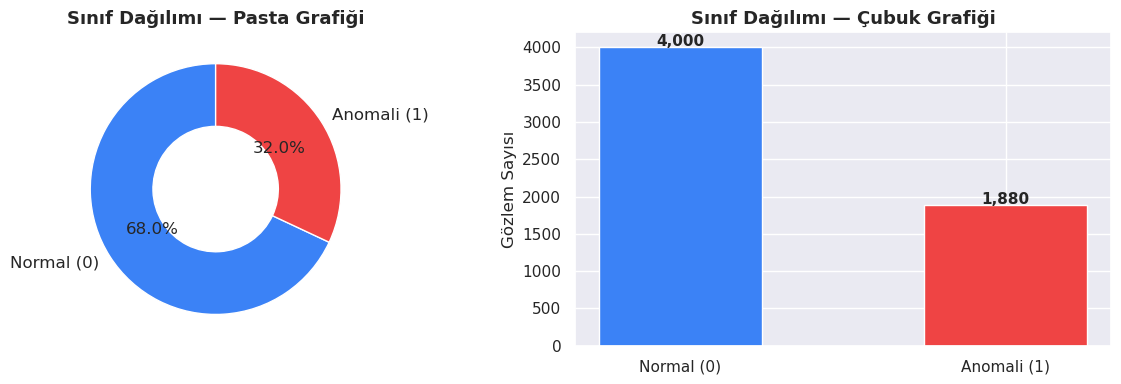

Sonuç: Veri dengesiz — Normal: %68.0, Anomali: %32.0
Bu nedenle Accuracy yerine F1-Score tercih edilmelidir.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pasta grafiği
counts = df["anomaly_label"].value_counts().sort_index()
axes[0].pie(
    counts.values,
    labels=["Normal (0)", "Anomali (1)"],
    autopct="%1.1f%%",
    colors=["#3b82f6", "#ef4444"],
    startangle=90,
    wedgeprops=dict(width=0.5),
    textprops={"fontsize": 12}
)
axes[0].set_title("Sınıf Dağılımı — Pasta Grafiği", fontsize=13, fontweight="bold")

# Çubuk grafiği
bars = axes[1].bar(["Normal (0)", "Anomali (1)"], counts.values,
                   color=["#3b82f6", "#ef4444"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Sınıf Dağılımı — Çubuk Grafiği", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Gözlem Sayısı")

plt.tight_layout()
plt.show()

print(f"Sonuç: Veri dengesiz — Normal: %{counts[0]/len(df)*100:.1f}, Anomali: %{counts[1]/len(df)*100:.1f}")
print("Bu nedenle Accuracy yerine F1-Score tercih edilmelidir.")


### Görsel 2 — Hastalık / Hücre Kategorisi Dağılımı

**Amaç:** Veri setindeki 8 farklı hastalık/hücre kategorisinin dağılımını görmek.  
Hangi kategorinin daha fazla temsil edildiğini anlamak, model performansını
değerlendirirken önemlidir.


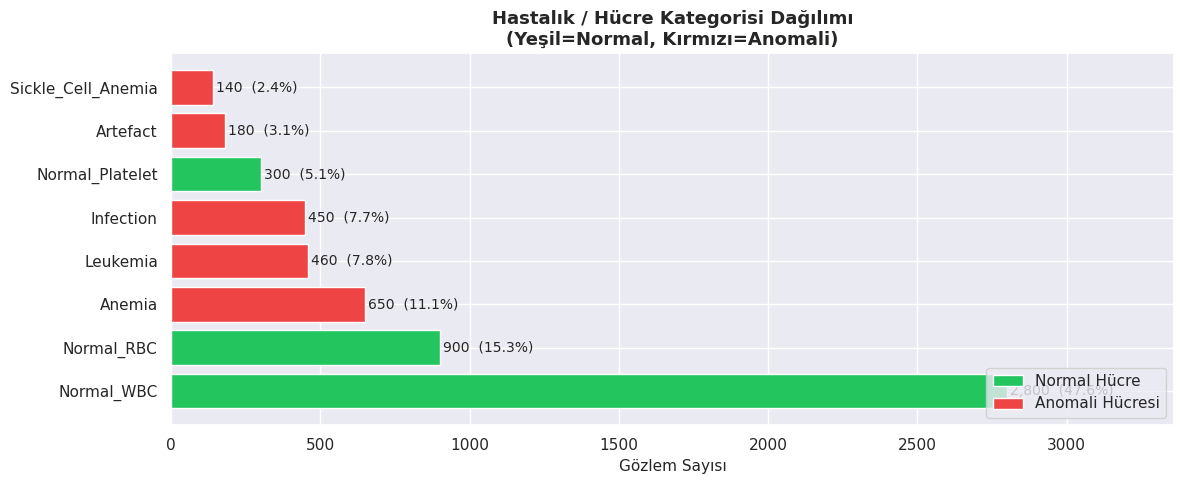

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

cat_counts = df["disease_category"].value_counts()
colors = ["#22c55e" if "Normal" in c else "#ef4444" for c in cat_counts.index]

bars = ax.barh(cat_counts.index, cat_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({val/len(df):.1%})", va="center", fontsize=10)

ax.set_xlabel("Gözlem Sayısı", fontsize=11)
ax.set_title("Hastalık / Hücre Kategorisi Dağılımı\n(Yeşil=Normal, Kırmızı=Anomali)",
             fontsize=13, fontweight="bold")
ax.set_xlim(0, cat_counts.max() * 1.2)

from matplotlib.patches import Patch
legend = [Patch(facecolor="#22c55e", label="Normal Hücre"),
          Patch(facecolor="#ef4444", label="Anomali Hücresi")]
ax.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.show()


### Görsel 3 — Korelasyon Isı Haritası (Correlation Heatmap)

**Amaç:** Sayısal değişkenler arasındaki doğrusal ilişkiyi ölçmek.
- **+1'e yakın:** Güçlü pozitif korelasyon (birlikte artar)  
- **-1'e yakın:** Güçlü negatif korelasyon (biri artarken diğeri azalır)  
- **0'a yakın:** İlişki yok  

Yüksek korelasyonlu çiftler çoklu doğrusallığa (multicollinearity) yol açabilir.


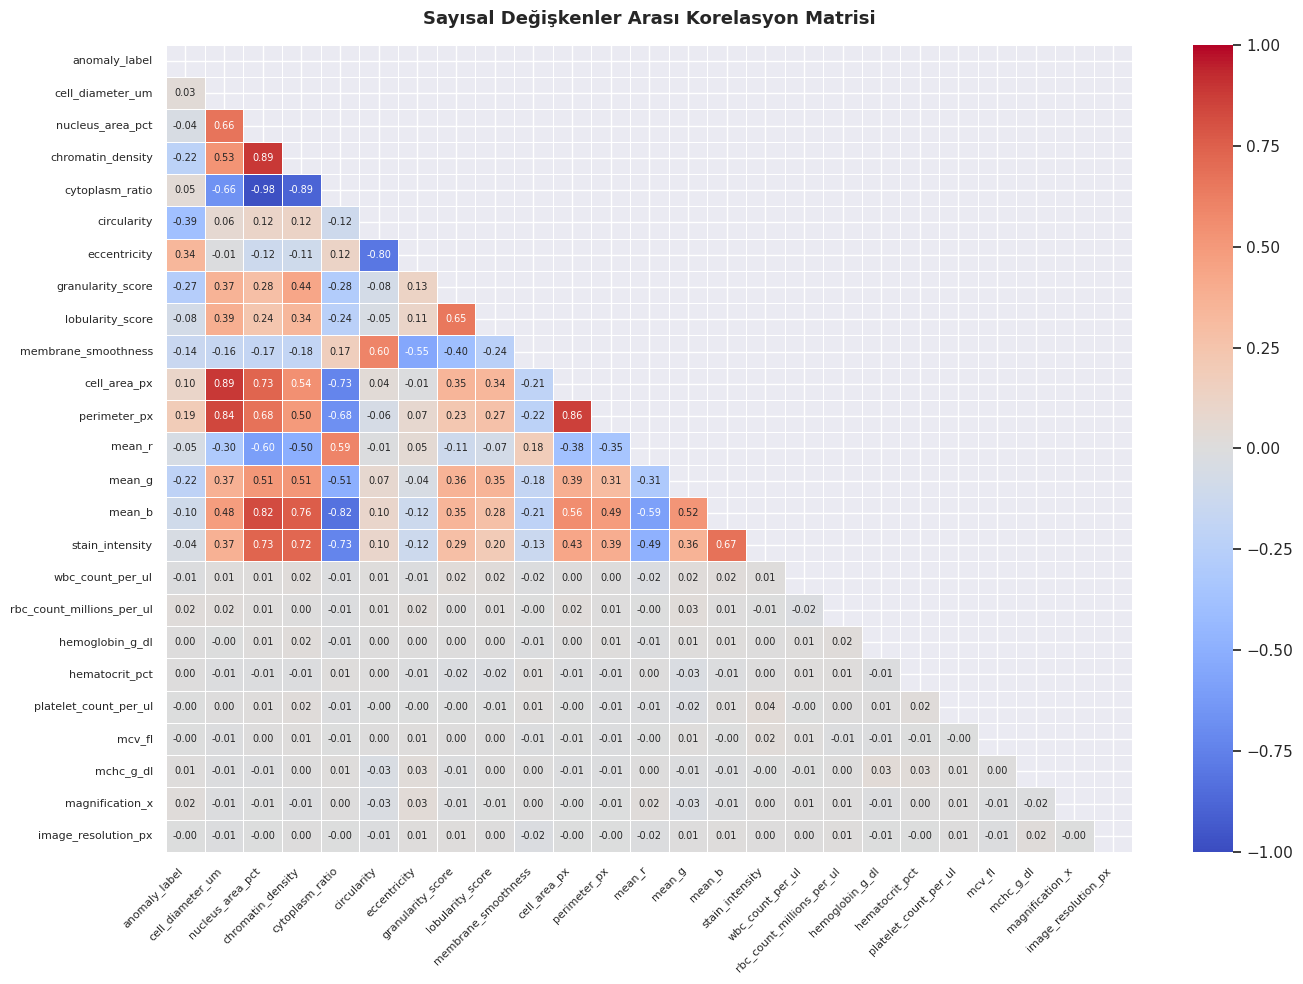

Top 5 korelasyon çifti:
cytoplasm_ratio    nucleus_area_pct     0.981113
chromatin_density  nucleus_area_pct     0.887461
cell_area_px       cell_diameter_um     0.887456
cytoplasm_ratio    chromatin_density    0.885985
perimeter_px       cell_area_px         0.862552
                   cell_diameter_um     0.840455
mean_b             nucleus_area_pct     0.824723
                   cytoplasm_ratio      0.823539
eccentricity       circularity          0.804000
mean_b             chromatin_density    0.758764


In [9]:
# Sayısal sütunlar seç (leakage hariç)
heatmap_cols = [c for c in df.select_dtypes("number").columns
                if c not in ["cytodiffusion_anomaly_score",
                             "cytodiffusion_classification_confidence",
                             "labeller_confidence_score"]]

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # üst üçgeni gizle

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 7},
            vmin=-1, vmax=1)

ax.set_title("Sayısal Değişkenler Arası Korelasyon Matrisi",
             fontsize=13, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# En yüksek korelasyonlu çiftler
corr_unstacked = corr.where(mask == False).stack().abs().sort_values(ascending=False)
print("Top 5 korelasyon çifti:")
print(corr_unstacked.drop_duplicates().head(10).to_string())


### Görsel 4 — Önemli Özelliklerin Sınıf Bazlı Dağılımı (KDE Plot)

**KDE (Kernel Density Estimate):** Her sınıfın (Normal / Anomali) bir özellik
üzerindeki olasılık yoğunluğunu gösterir.

**Yorumlama:** İki eğri birbirinden ne kadar uzaksa, o özellik iki sınıfı o kadar
iyi ayırt eder — bu özelliğin modelde önemli olacağını gösterir.


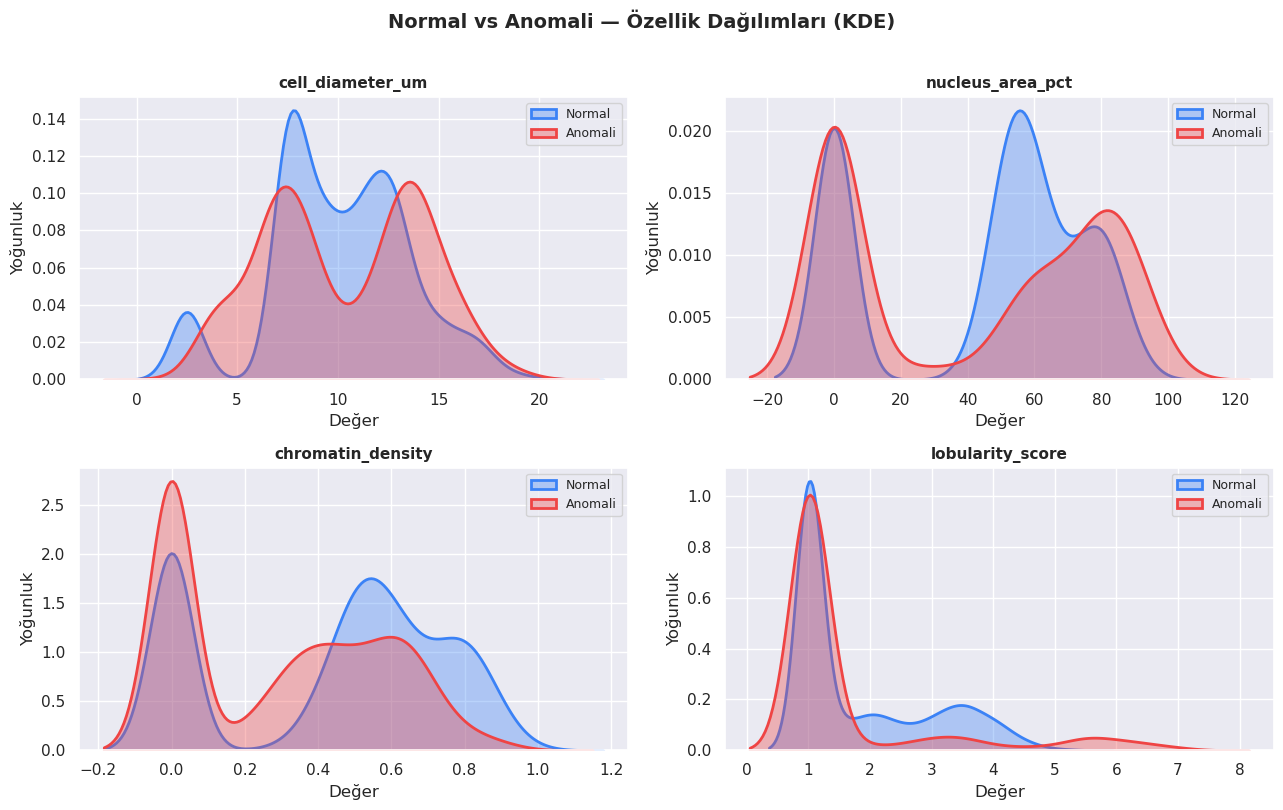

Gözlem: Dağılımlar arasındaki mesafe büyük → bu özellikler ayırt edici.


In [10]:
features = ["cell_diameter_um", "nucleus_area_pct",
            "chromatin_density", "lobularity_score"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color, name in [(0, "#3b82f6", "Normal"), (1, "#ef4444", "Anomali")]:
        data = df[df["anomaly_label"] == label][feat].dropna()
        sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.35, label=name, linewidth=2)
    ax.set_title(f"{feat}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Değer")
    ax.set_ylabel("Yoğunluk")
    ax.legend(fontsize=9)

plt.suptitle("Normal vs Anomali — Özellik Dağılımları (KDE)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Gözlem: Dağılımlar arasındaki mesafe büyük → bu özellikler ayırt edici.")


### Görsel 5 — Kan Değerleri Kutu Grafiği (Boxplot)

**Boxplot:** Bir değişkenin dağılımını (min, Q1, medyan, Q3, max) ve aykırı
değerleri (outlier) görselleştirir.

- **Kutu:** Q1-Q3 arası (%50 veri)  
- **Orta çizgi:** Medyan  
- **Bıyıklar:** 1.5×IQR sınırı  
- **Noktalar:** Aykırı değerler  

Anomali ve normal hücreler arasındaki kan değeri farklarını gösterir.


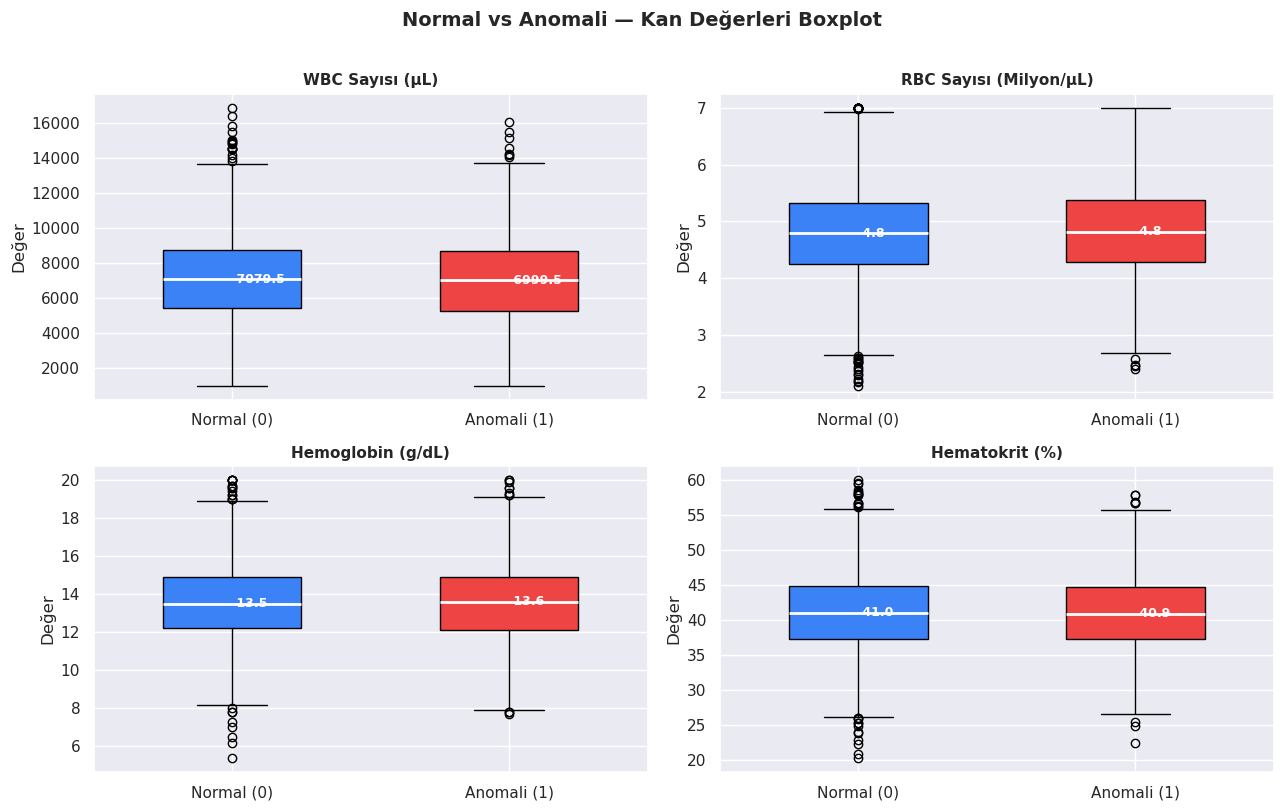

In [11]:
blood_features = ["wbc_count_per_ul", "rbc_count_millions_per_ul",
                  "hemoglobin_g_dl", "hematocrit_pct"]
titles = ["WBC Sayısı (μL)", "RBC Sayısı (Milyon/μL)",
          "Hemoglobin (g/dL)", "Hematokrit (%)"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(blood_features, titles)):
    ax = axes[i]
    data_groups = [df[df["anomaly_label"] == 0][feat],
                   df[df["anomaly_label"] == 1][feat]]
    bp = ax.boxplot(data_groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor("#3b82f6")
    bp["boxes"][1].set_facecolor("#ef4444")
    ax.set_xticklabels(["Normal (0)", "Anomali (1)"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Değer")
    # Medyan değerleri yaz
    for j, group in enumerate(data_groups):
        med = group.median()
        ax.text(j+1, med, f" {med:.1f}", va="center", fontsize=9, color="white",
                fontweight="bold")

plt.suptitle("Normal vs Anomali — Kan Değerleri Boxplot",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## ✅ Özet

### Veri Ön İşleme (5 Adım)
| # | Adım | Açıklama |
|---|------|----------|
| 1 | Veri Yükleme | CSV okundu, boyut ve tipler incelendi |
| 2 | Kalite Kontrolü | Eksik değer yok, duplikasyon yok |
| 3 | Leakage Temizliği | 5 sütun + 1 ID sütunu çıkarıldı |
| 4 | One-Hot Encoding + Split | Kategorikler sayısala çevrildi, %80/%20 stratified bölme |
| 5 | StandardScaler | Sayısal değişkenler normalize edildi (sadece train'de fit) |

### EDA (5 Görsel)
| # | Görsel | Bulgu |
|---|--------|-------|
| 1 | Sınıf Dağılımı | Veri dengesiz: %68 Normal, %32 Anomali |
| 2 | Kategori Dağılımı | Normal_WBC en kalabalık sınıf (%47) |
| 3 | Korelasyon Haritası | `cell_area_px` ↔ `perimeter_px` yüksek korelasyon |
| 4 | KDE Grafikleri | `nucleus_area_pct`, `chromatin_density` ayırt edici |
| 5 | Boxplot | Anomalilerde WBC sayısı belirgin şekilde farklı |
